<a href="https://colab.research.google.com/github/AWEN-JOSH/Thrive_Internship_ML_A/blob/main/Customer_Support_Classifier_Project_josh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

upload  CSV

In [2]:
from google.colab import files
uploaded = files.upload()

Saving 01_customer_support_tickets_clean_group-b.csv to 01_customer_support_tickets_clean_group-b.csv


Build Baseline Models
 Install & Import Libraries

In [3]:
!pip install scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

Load Your Data

In [4]:
# Load the dataset
df = pd.read_csv("01_customer_support_tickets_clean_group-b.csv")

# Check first few rows
print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df['label'].value_counts())

# Keep only needed columns
df = df[['text', 'label']].dropna()

Dataset shape: (495, 4)

Label distribution:
label
other           166
tech_support    119
billing         113
account          97
Name: count, dtype: int64


3: Train/Test Split

In [5]:
X = df['text']
y = df['label']

# Stratified split to keep label balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 396 | Test size: 99


4: Majority (Dummy) Classifier

In [6]:
# Always predicts the most frequent class
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy, average='weighted')

print("=== Majority Classifier ===")
print(f"Accuracy: {acc_dummy:.4f}")
print(f"Weighted F1: {f1_dummy:.4f}")

=== Majority Classifier ===
Accuracy: 0.3333
Weighted F1: 0.1667


 5: TF-IDF + Logistic Regression

In [7]:
# Vectorize text
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)  # unigrams + bigrams
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_vec, y_train)
y_pred_lr = lr.predict(X_test_vec)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

print("\n=== TF-IDF + Logistic Regression ===")
print(f"Accuracy: {acc_lr:.4f}")
print(f"Weighted F1: {f1_lr:.4f}")


=== TF-IDF + Logistic Regression ===
Accuracy: 0.9394
Weighted F1: 0.9387


6: Confusion Matrices

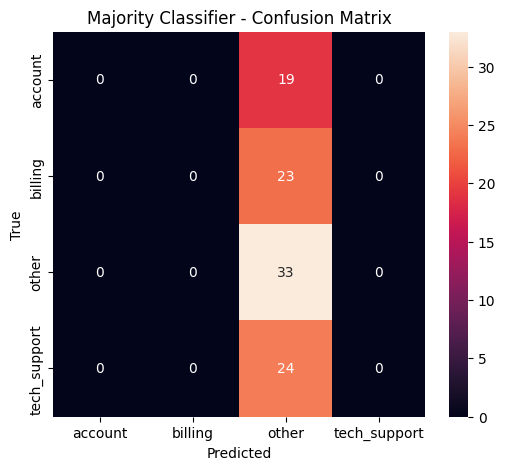

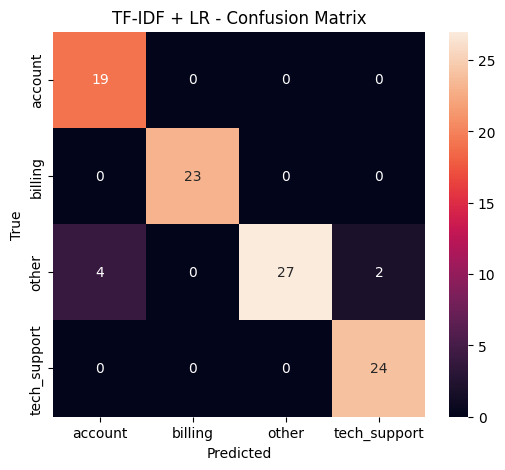

In [8]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(y.unique()))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
    plt.title(title)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

plot_confusion_matrix(y_test, y_pred_dummy, "Majority Classifier - Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_lr, "TF-IDF + LR - Confusion Matrix")

Save Baseline Metrics

In [9]:
os.makedirs("artifacts", exist_ok=True)

baseline_metrics = {
    "majority_classifier": {
        "accuracy": float(acc_dummy),
        "weighted_f1": float(f1_dummy)
    },
    "tfidf_logistic_regression": {
        "accuracy": float(acc_lr),
        "weighted_f1": float(f1_lr)
    }
}

with open("artifacts/baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=4)

print("✅ Baseline metrics saved!")

✅ Baseline metrics saved!


Fine-tune DistilBERT
 Install Hugging Face Libraries

In [10]:
!pip install transformers datasets accelerate scikit-learn

re-run import

In [11]:
import pandas as pd
import numpy as np
import os
import json
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from sklearn.metrics import accuracy_score, f1_score

2: Reload Data & Encode Labels

In [12]:
df = pd.read_csv("01_customer_support_tickets_clean_group-b.csv")[['text', 'label']].dropna()

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Encode labels to integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Classes:", le.classes_)

Classes: ['account' 'billing' 'other' 'tech_support']


3: Create Hugging Face Datasets

In [13]:
train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train_enc.tolist()})
test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test_enc.tolist()})

4: Tokenize with DistilBERT

In [14]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True, max_length=128)

train_tokenized = train_dataset.map(tokenize, batched=True, batch_size=32)
test_tokenized = test_dataset.map(tokenize, batched=True, batch_size=32)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/396 [00:00<?, ? examples/s]

Map:   0%|          | 0/99 [00:00<?, ? examples/s]

5: Load Model

In [15]:
num_labels = len(le.classes_)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label={i: label for i, label in enumerate(le.classes_)},
    label2id={label: i for i, label in enumerate(le.classes_)}
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


6: Define Metrics

In [16]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

7: Set Up Training

In [20]:
evaluation_strategy="epoch"


In [21]:
evaluate_during_training=True


In [22]:
import transformers
print(transformers.__version__)


4.57.1


In [23]:
import pandas as pd
import numpy as np
import os
import json
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from sklearn.metrics import accuracy_score, f1_score

re-load encouded data

In [24]:
df = pd.read_csv("01_customer_support_tickets_clean_group-b.csv")[['text', 'label']].dropna()

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Encode labels to integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Classes:", le.classes_)

Classes: ['account' 'billing' 'other' 'tech_support']


3: Create Hugging Face Datasets

In [25]:
train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train_enc.tolist()})
test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test_enc.tolist()})

4: Tokenize with DistilBERT

In [26]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True, max_length=128)

train_tokenized = train_dataset.map(tokenize, batched=True, batch_size=32)
test_tokenized = test_dataset.map(tokenize, batched=True, batch_size=32)

Map:   0%|          | 0/396 [00:00<?, ? examples/s]

Map:   0%|          | 0/99 [00:00<?, ? examples/s]

5: Load Model

In [27]:
num_labels = len(le.classes_)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label={i: label for i, label in enumerate(le.classes_)},
    label2id={label: i for i, label in enumerate(le.classes_)}
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


6: Define Metrics

In [28]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

7: Set Up Training

In [31]:
os.makedirs("models/distilbert-ticket-classifier", exist_ok=True)

training_args = TrainingArguments(
    output_dir="models/distilbert-ticket-classifier",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    warmup_ratio=0.1,
    weight_decay=0.01,
    report_to="none"
)

In [32]:
evaluation_strategy="epoch",

In [34]:
eval_strategy="epoch",

In [36]:
training_args = TrainingArguments(
    output_dir="models/distilbert-ticket-classifier",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",           # ← FIXED! Was "evaluation_strategy"
    save_strategy="epoch",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    warmup_ratio=0.1,
    weight_decay=0.01,
    report_to="none"
)

 8: Train!

In [37]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print("🚀 Starting DistilBERT fine-tuning...")
trainer.train()

/tmp/ipython-input-3929831028.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


🚀 Starting DistilBERT fine-tuning...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.081900,0.615273,0.818182,0.785434
2,0.428200,0.273472,0.939394,0.938692
3,0.309300,0.254553,0.939394,0.938692


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=75, training_loss=0.6179506333669027, metrics={'train_runtime': 218.8618, 'train_samples_per_second': 5.428, 'train_steps_per_second': 0.343, 'total_flos': 5840157752352.0, 'train_loss': 0.6179506333669027, 'epoch': 3.0})

9: Save Model & Metrics

In [38]:
# Evaluate final performance
results = trainer.evaluate()

distilbert_metrics = {
    "accuracy": float(results["eval_accuracy"]),
    "weighted_f1": float(results["eval_f1"])
}

# Save model and tokenizer
trainer.save_model("models/distilbert-ticket-classifier")
tokenizer.save_pretrained("models/distilbert-ticket-classifier")

# Save metrics
with open("artifacts/distilbert_metrics.json", "w") as f:
    json.dump(distilbert_metrics, f, indent=4)

print("✅ DistilBERT model and metrics saved!")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


✅ DistilBERT model and metrics saved!


Compare All Models
Load All Metrics

In [39]:
with open("artifacts/baseline_metrics.json") as f:
    baseline = json.load(f)
with open("artifacts/distilbert_metrics.json") as f:
    distilbert = json.load(f)

comparison = pd.DataFrame({
    "Model": [
        "Majority Classifier",
        "TF-IDF + Logistic Regression",
        "DistilBERT (Fine-tuned)"
    ],
    "Accuracy": [
        baseline["majority_classifier"]["accuracy"],
        baseline["tfidf_logistic_regression"]["accuracy"],
        distilbert["accuracy"]
    ],
    "Weighted F1": [
        baseline["majority_classifier"]["weighted_f1"],
        baseline["tfidf_logistic_regression"]["weighted_f1"],
        distilbert["weighted_f1"]
    ]
})

print(comparison)

                          Model  Accuracy  Weighted F1
0           Majority Classifier  0.333333     0.166667
1  TF-IDF + Logistic Regression  0.939394     0.938692
2       DistilBERT (Fine-tuned)  0.939394     0.938692


 2: Save Comparison

In [40]:
os.makedirs("artifacts", exist_ok=True)
comparison.to_csv("artifacts/model_comparison.csv", index=False)
print("✅ Model comparison saved!")

✅ Model comparison saved!


 3: Plot Comparison

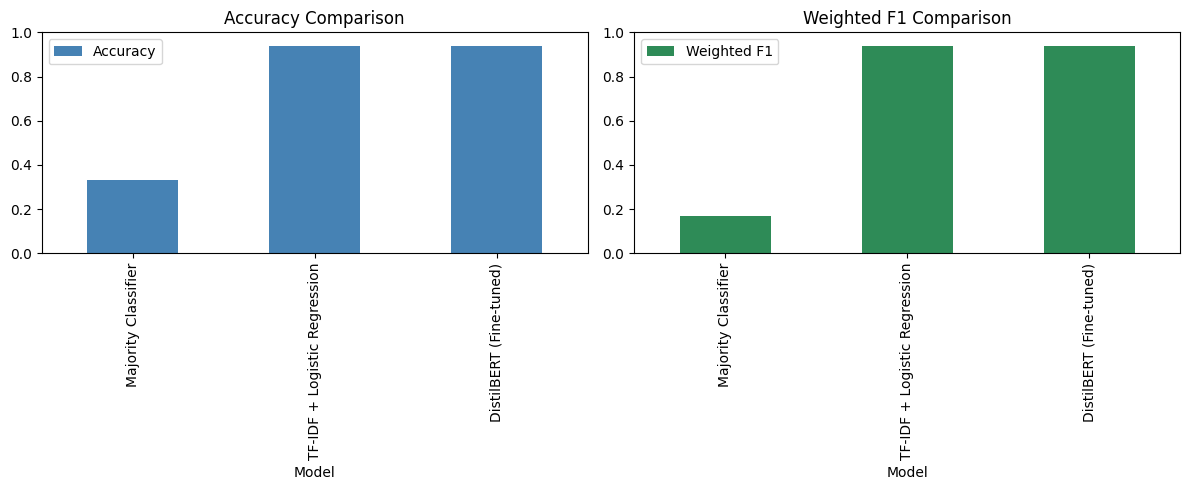

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

comparison.plot(x="Model", y="Accuracy", kind="bar", ax=ax[0], color='steelblue')
ax[0].set_title("Accuracy Comparison")
ax[0].set_ylim(0, 1)

comparison.plot(x="Model", y="Weighted F1", kind="bar", ax=ax[1], color='seagreen')
ax[1].set_title("Weighted F1 Comparison")
ax[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("artifacts/performance_comparison.png", dpi=150)
plt.show()

Build Gradio Demo
 Install Gradio

In [42]:
!pip install gradio

 2: Load Fine-tuned Model for Inference

In [43]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="models/distilbert-ticket-classifier",
    tokenizer="models/distilbert-ticket-classifier"
)

Device set to use cpu


 3: Create Gradio App

In [44]:
import gradio as gr

def classify_ticket(text):
    result = classifier(text)[0]
    return {result['label']: result['score']}

demo = gr.Interface(
    fn=classify_ticket,
    inputs=gr.Textbox(lines=3, placeholder="Enter customer ticket..."),
    outputs=gr.Label(),
    title="🎫 Customer Ticket Classifier",
    description="Powered by fine-tuned DistilBERT"
)

# Launch with public link
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://10eb76e1793319b92c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Final Documentatin
1: Generate README.md

In [45]:
# Get Gradio link (manually replace if needed)
gradio_link = "YOUR_GRADIO_LINK_HERE"  # ← Replace with actual link!

readme = f"""
# Customer Support Ticket Classifier

## 📊 Performance Summary

| Model                        | Accuracy | Weighted F1 |
|-----------------------------|----------|-------------|
"""

for _, row in comparison.iterrows():
    readme += f"| {row['Model']} | {row['Accuracy']:.4f} | {row['Weighted F1']:.4f} |\n"

readme += f"""
## 🏆 Best Model
**DistilBERT (Fine-tuned)** outperforms baselines.

## ▶️ Try the Demo
Live demo: [{gradio_link}]({gradio_link})

## 📁 Project Structure
- `artifacts/`: Metrics and plots
- `models/`: Saved DistilBERT model
- `deployment/`: Gradio app

## 🧪 How to Reproduce
1. Run baseline models
2. Fine-tune DistilBERT
3. Launch Gradio demo
"""

with open("README.md", "w") as f:
    f.write(readme)

print("✅ README.md generated!")

✅ README.md generated!
